In [2]:
import math
import matplotlib.pyplot as plt
ts_teal = '#00DBBC'
ts_orange = '#FF8B25'
ts_gray = '#909090'
ts_yellow = '#EBC247'
ts_red ='#EB5347'
ts_orange ='#FF8B25'
ts_purple ='#D65BB3'
ts_lblue ='#47C6EB'
ts_fusia ='#E82166'
ts_lime ='#BAEB47'
ts_sand ='#EB7347'
ts_dpurple ='#9747FF'
ts_pblue ='#87FFEE'
ts_dgreen ='#007564'
ts_gray ='#909090'
ts_green ='#00B20F'
ts_brown ='#BD7536'
ts_rblue ='#008BDB'
bg = '#1a1a1a'



def decay(n, tau):
    tempdecay = 1 - math.exp(-n / tau)
    return tempdecay

def simple_conviction(n, b0, tau):
    tempdecay = decay(n, tau)
    conv = b0*tempdecay
    return conv

def owner_conviction(n, b0, incrate, tau):
    tempdecay = decay(n, tau)
    conv = b0*tempdecay + incrate*(n-tau*tempdecay)
    return conv
    
def attacker_conviction(n, k, bk, rate, tau):
    """
    Absolute conviction at block n for a tranche of bk alpha added at block k.
    No ongoing emissions — pure time-based conviction on a fixed deposit.
    Returns 0 if n < k.
    """
    if n < k:
        return 0.0
    delta = n - k
    tempdecay = decay(delta, tau)
    conviction = bk*tempdecay + rate * (delta - tau * tempdecay)
    return conviction

def unlock_to_available(n, amount, tau):
    tempdecay = decay(n, tau)
    avail = amount*tempdecay
    return avail

In [4]:
#conviction
tau = 90 #tau in days is 648000 if in blocks
counter =0
b0 = 10000

print(f"Conviction over time after locking {b0} alpha\n")
print("Days     Conviction")
while counter < 365:
    conviction = simple_conviction(counter, b0, tau)
    if  counter %62 ==0:
        print(f"{counter:3}        {round(conviction,1)}")
    counter +=1
    


Conviction over time after locking 10000 alpha

Days     Conviction
  0        0.0
 62        4978.7
124        7478.6
186        8733.9
248        9364.3
310        9680.8


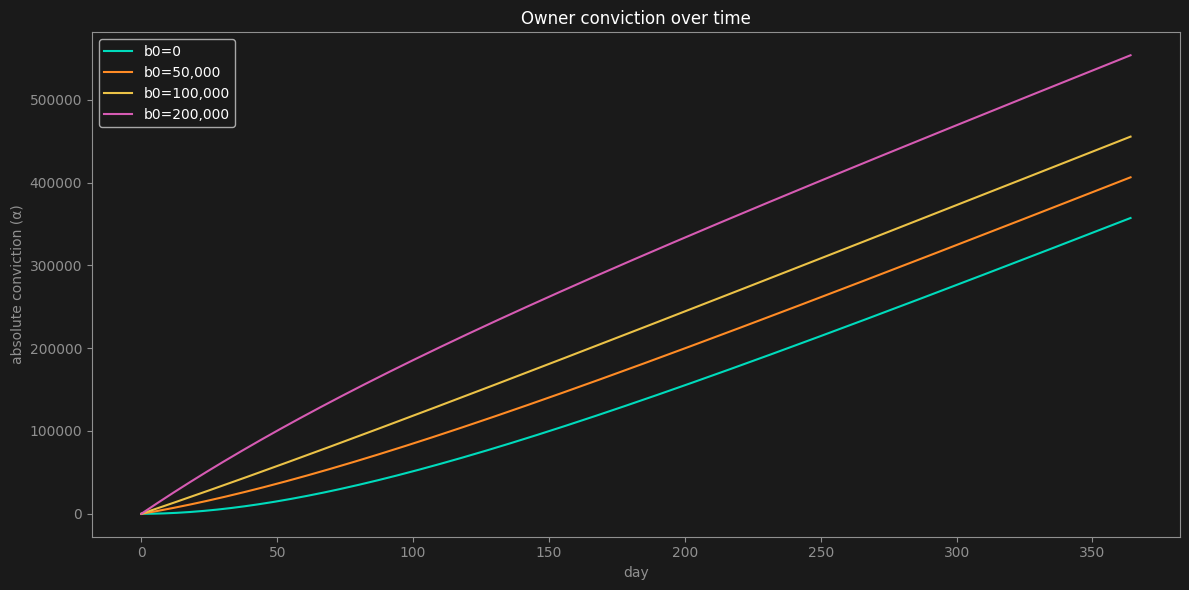

In [40]:
#subnet owner conviction - where there is an initial lock of b0, and 0.18 lcoked per block (1296 locked per day)
#this assumes no unlocks

tau = 90 #tau in days is 648000 if in blocks
rate = 1296 #1296 alpha per day 0.18 per block)
counter =0
b0s = [0, 50000, 100000,200000] 

owner_conviction_data = {}
counter = 0
while counter<365:
    owner_conviction_data[counter] = {} 
    for b0 in b0s:
        owner_conv = owner_conviction(counter, b0, rate, tau)
        owner_conviction_data[counter][b0]=owner_conv
    counter +=1

days = list(owner_conviction_data.keys())

fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)

colors = [ts_teal, ts_orange, ts_yellow, ts_purple]
for b0, color in zip(b0s, colors):
    series = [owner_conviction_data[day][b0] for day in days]
    ax.plot(days, series, label=f'b0={b0:,}', color=color)

#ax.plot(days, owner_conv, color=ts_teal, linewidth=2, label='Owner Conviction')
ax.set_xlabel('day', color=ts_gray)
ax.set_ylabel('absolute conviction (α)', color=ts_gray)
ax.set_title(f'Owner conviction over time', color='white')
ax.tick_params(colors=ts_gray)
ax.spines[:].set_color(ts_gray)
ax.legend(facecolor=bg, labelcolor='white')

plt.tight_layout()
plt.savefig('conviction.png', dpi=150, facecolor=bg)
plt.show()     

In [47]:
#unlock
#half life is 20.8 days, so displaying the available alpha every 21 days.

unlocked = 50000

tau = 30  #216000 in blocks

print(f"Amount available over time after unlocking {unlocked} alpha\n")
print("Days     Available")
counter = 0 
while counter <110:
    avail = unlock_to_available(counter, unlocked, tau)
    percent = round(avail/unlocked*100,2)
    if counter %21 ==0:
        print(f"{counter:3}        {round(avail,1):7} ({percent}%)")
    counter +=1

Amount available over time after unlocking 50000 alpha

Days     Available
  0            0.0 (0.0%)
 21        25170.7 (50.34%)
 42        37670.2 (75.34%)
 63        43877.2 (87.75%)
 84        46959.5 (93.92%)
105        48490.1 (96.98%)


In [129]:
#meaasuring conviction with unlocks
def conviction_full(n, b0, tau, rate,events=[]):
    TAU = tau
    EMISSION = rate
    
    stake = b0
    conv_offset = 0  # carried conviction from previous segments
    t_start = 0
    
    for (f, u) in sorted(events):
        if n <= f:
            break
        
        #change in time at the unlock moment
        dt = f - t_start
        #decay at the unlock moment
        temp_decay = decay(dt, TAU)
        # find the Conviction at the unlock moment
        conv_before_unlock = conv_offset + stake * temp_decay + EMISSION * (dt - TAU * temp_decay)
        
        conv_after_unlock= max(conv_before_unlock - u, 0) if u > 0 else conv_before_unlock
        conv_offset = conv_after_unlock
        stake = max(stake - u, 0)
        t_start = f
    
    dt = n - t_start
    #recalculate decal at the block
    temp_decay = decay(dt, TAU)
    return conv_offset + stake * temp_decay + EMISSION * (dt - TAU * temp_decay)

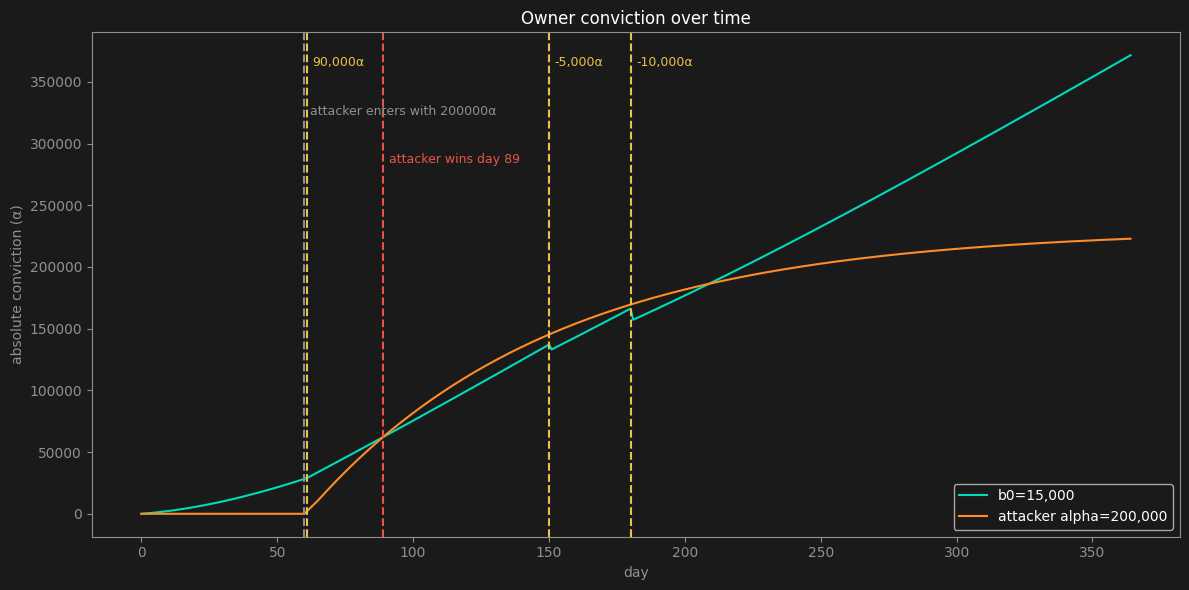

In [145]:
#simulate an attack on a subnet for subnet king

#math in days not blocks
tau = 90
rate = 1296

#subnet owner
#each event is a (date, withdrawl in alpha). To add stake, withdraw a negative value
events = [(61, -90000),(150, 5000),(180, 10000)]
#inital SN owner lock
b0=15000

#attacker
#each event is a (date, withdrawl in alpha). To add stake, withdraw a negative value
attacker_events = [(60, -200000),(65, -20000)]



#math
attacker_conviction_data = {}
counter =0
while counter <365:
    attack = conviction_full(counter, 0, tau,0, attacker_events)
    attacker_conviction_data[counter]=attack
    counter +=1






#math - no need to modify
conviction_complex = {}
counter =0
crossoverdate = 365
crossover = False

while counter <365:
    conv = conviction_full(counter, b0, tau, rate, events)
    conviction_complex[counter] = conv
    
    #did the attacker win?
    if attacker_conviction_data[counter]> conv and counter >1:
        if crossover == False:
            crossover = True
            crossoverdate = counter
    counter +=1


days = list(conviction_complex.keys())

fig, ax = plt.subplots(figsize=(12, 6), facecolor=bg)
ax.set_facecolor(bg)


series = [conviction_complex[day] for day in days]
ax.plot(days, series, label=f'b0={b0:,}', color=ts_teal)

attacker_series = [attacker_conviction_data[day] for day in days]
ax.plot(days, attacker_series, label=f'attacker alpha={attack_amt:,}', color=ts_orange)

for (f, u) in events:
    ax.axvline(x=f, color=ts_yellow, linewidth=1.5, linestyle='--')
    ax.text(f + 2, ax.get_ylim()[1] * 0.95, f'{-u:,}α', color=ts_yellow, fontsize=9, va='top')

#attacker enters
ax.axvline(x=attack_day, color=ts_gray, linewidth=1.5, linestyle='--')
ax.text(attack_day +2, ax.get_ylim()[1] * 0.85, f'attacker enters with {attack_amt}α', color=ts_gray, fontsize=9, va='top')

#if attacker wins

if crossoverdate< 365:
    ax.axvline(x=crossoverdate, color=ts_red, linewidth=1.5, linestyle='--')
    ax.text(crossoverdate +2, ax.get_ylim()[1] * 0.75, f'attacker wins day {crossoverdate}', color=ts_red, fontsize=9, va='top')

#ax.plot(days, owner_conv, color=ts_teal, linewidth=2, label='Owner Conviction')
ax.set_xlabel('day', color=ts_gray)
ax.set_ylabel('absolute conviction (α)', color=ts_gray)
ax.set_title(f'Owner conviction over time', color='white')
ax.tick_params(colors=ts_gray)
ax.spines[:].set_color(ts_gray)
ax.legend(facecolor=bg, labelcolor='white')

plt.tight_layout()
plt.savefig('conviction.png', dpi=150, facecolor=bg)
plt.show()        